# Notebook 02 — SAE Training
Trains one SAE per layer (layers 4 and 12). Logs MSE, L0, dead features every 1k steps.
Target L0: 5–50 active features per token. Adjust alpha if outside this range.

In [1]:
import sys, os
sys.path.insert(0, '..')
import torch
import matplotlib.pyplot as plt
from src.sae import SAE

DEVICE         = 'cuda'
D_INPUT        = 768
D_HIDDEN       = 3072
ALPHA_L4  = 6e-3  # warmup prevents early collapse; 1e-2 gave L0~80, 2e-2 collapsed to L0~9
ALPHA_L8  = 5e-3    # keep same target; warmup fixes early-death redundancy
ALPHA_L12 = 5e-3    # layer 12: target L0 30-50
LR             = 1e-4
BATCH          = 2048
N_STEPS        = 100_000
WARMUP_STEPS   = 20_000
LOG_EVERY      = 1_000
RESAMPLE_STEPS = {30_000, 50_000, 75_000}  # shifted from 25k: first resample after warmup stabilises
os.makedirs('../checkpoints', exist_ok=True)

In [2]:
def resample_dead_neurons(sae, x_pool, opt, dead_mask, device):
    """Reinitialize dead neurons with high-reconstruction-error samples.

    x_pool: (M, d_input) normalized float tensor on CPU.
    """
    n_dead = dead_mask.sum().item()
    if n_dead == 0:
        return 0

    with torch.no_grad():
        x = x_pool.to(device)
        _, x_hat = sae(x)
        errors = ((x - x_hat) ** 2).sum(dim=-1)

        probs = errors / errors.sum()
        chosen = torch.multinomial(probs, n_dead, replacement=True)
        dirs = x[chosen]
        dirs = dirs / dirs.norm(dim=-1, keepdim=True).clamp(min=1e-8)

        sae.W_e.data[dead_mask] = dirs * 0.2
        sae.b_e.data[dead_mask] = 0.0
        sae.W_d.data[:, dead_mask] = dirs.T

        for p in [sae.W_e, sae.b_e, sae.W_d]:
            if p in opt.state and 'exp_avg' in opt.state[p]:
                if p is sae.W_d:
                    opt.state[p]['exp_avg'][:, dead_mask] = 0
                    opt.state[p]['exp_avg_sq'][:, dead_mask] = 0
                else:
                    opt.state[p]['exp_avg'][dead_mask] = 0
                    opt.state[p]['exp_avg_sq'][dead_mask] = 0

    return n_dead

In [4]:
def train_sae(acts_path: str, save_path: str, label: str, alpha: float) -> dict:
    acts = torch.load(acts_path, weights_only=False)  # (N*197, 768) on CPU — full tensor

    N = acts.shape[0] // 197
    img_starts    = torch.arange(N) * 197
    patch_indices = (img_starts.unsqueeze(1) + torch.arange(1, 197).unsqueeze(0)).reshape(-1)
    n_patch = len(patch_indices)   # N * 196

    CHUNK = 8192
    acts_mean = torch.zeros(D_INPUT)
    for i in range(0, n_patch, CHUNK):
        acts_mean += acts[patch_indices[i:i+CHUNK]].float().sum(dim=0)
    acts_mean /= n_patch

    sos = 0.0
    for i in range(0, n_patch, CHUNK):
        chunk = acts[patch_indices[i:i+CHUNK]].float() - acts_mean
        sos += chunk.pow(2).sum().item()
    acts_rms     = torch.tensor(max((sos / (n_patch * D_INPUT)) ** 0.5, 1e-8))
    acts_rms_val = acts_rms.item()

    acts_mean_dev = acts_mean.to(DEVICE)

    sae = SAE(d_input=D_INPUT, d_hidden=D_HIDDEN, alpha=alpha).to(DEVICE)
    opt = torch.optim.Adam(sae.parameters(), lr=LR)

    log  = {k: [] for k in ('step', 'total', 'mse', 'l1', 'l0', 'dead_pct')}
    perm = torch.randperm(n_patch)
    ptr  = 0
    step = 0

    while step < N_STEPS:
        if ptr + BATCH > n_patch:
            perm = torch.randperm(n_patch)
            ptr  = 0

        batch_pi = patch_indices[perm[ptr:ptr + BATCH]]
        ptr += BATCH
        x = (acts[batch_pi].to(DEVICE).float() - acts_mean_dev) / acts_rms_val

        f, x_hat = sae(x)
        alpha_eff = alpha * min(1.0, step / WARMUP_STEPS)  # linear warmup
        total, mse, l1 = sae.loss(x, f, x_hat, alpha=alpha_eff)
        opt.zero_grad(); total.backward(); opt.step()
        sae.normalize_decoder()

        if step in RESAMPLE_STEPS:
            eval_pi    = patch_indices[torch.randperm(n_patch)[:50_000]]
            ever_fired = torch.zeros(D_HIDDEN, dtype=torch.bool)
            sae.eval()
            with torch.no_grad():
                for i in range(0, len(eval_pi), BATCH):
                    xb = (acts[eval_pi[i:i+BATCH]].to(DEVICE).float() - acts_mean_dev) / acts_rms_val
                    fb, _ = sae(xb)
                    ever_fired |= (fb > 0).any(dim=0).cpu()
            sae.train()
            dead_mask = ~ever_fired

            resamp_pi = patch_indices[torch.randperm(n_patch)[:4096]]
            x_pool    = (acts[resamp_pi].float() - acts_mean) / acts_rms_val
            n = resample_dead_neurons(sae, x_pool, opt, dead_mask, DEVICE)
            print(f'  [{label}] step {step}: resampled {n} dead neurons '
                  f'({dead_mask.float().mean()*100:.1f}% were dead on 50k eval)')

        if step % LOG_EVERY == 0:
            with torch.no_grad():
                l0       = (f > 0).float().sum(dim=1).mean().item()
                dead_pct = ((f > 0).float().sum(dim=0) == 0).float().mean().item() * 100
            log['step'].append(step)
            log['total'].append(total.item())
            log['mse'].append(mse.item())
            log['l1'].append(l1.item())
            log['l0'].append(l0)
            log['dead_pct'].append(dead_pct)
            print(f'[{label}] step={step:6d} | mse={mse.item():.4f} | '
                  f'l0={l0:.1f} | dead={dead_pct:.1f}% | alpha_eff={alpha_eff:.2e}')
        step += 1

    # Post-training resampling
    eval_pi    = patch_indices[torch.randperm(n_patch)[:50_000]]
    ever_fired = torch.zeros(D_HIDDEN, dtype=torch.bool)
    sae.eval()
    with torch.no_grad():
        for i in range(0, len(eval_pi), BATCH):
            xb = (acts[eval_pi[i:i+BATCH]].to(DEVICE).float() - acts_mean_dev) / acts_rms_val
            fb, _ = sae(xb)
            ever_fired |= (fb > 0).any(dim=0).cpu()
    sae.train()
    dead_mask = ~ever_fired
    resamp_pi = patch_indices[torch.randperm(n_patch)[:4096]]
    x_pool    = (acts[resamp_pi].float() - acts_mean) / acts_rms_val
    n = resample_dead_neurons(sae, x_pool, opt, dead_mask, DEVICE)
    print(f'  [{label}] post-training resample: {n} dead '
          f'({dead_mask.float().mean()*100:.1f}% were dead)')

    torch.save({'state_dict': sae.state_dict(), 'log': log,
                'acts_mean': acts_mean.cpu(), 'acts_rms': acts_rms.cpu(),
                'alpha': alpha, 'token_type': 'patch_only'}, save_path)
    print(f'Saved {save_path}')
    return log

In [5]:
log4 = train_sae('../data/layer4_activations.pt', '../checkpoints/sae_layer4.pt',
                 'layer4', alpha=ALPHA_L4)

[layer4] step=     0 | mse=1.1835 | l0=1536.2 | dead=0.0% | alpha_eff=0.00e+00
[layer4] step=  1000 | mse=0.0622 | l0=1562.8 | dead=0.0% | alpha_eff=3.00e-04
[layer4] step=  2000 | mse=0.0849 | l0=1136.2 | dead=0.0% | alpha_eff=6.00e-04
[layer4] step=  3000 | mse=0.1205 | l0=764.7 | dead=0.0% | alpha_eff=9.00e-04
[layer4] step=  4000 | mse=0.1497 | l0=543.9 | dead=0.0% | alpha_eff=1.20e-03
[layer4] step=  5000 | mse=0.1714 | l0=404.1 | dead=0.0% | alpha_eff=1.50e-03
[layer4] step=  6000 | mse=0.1919 | l0=319.9 | dead=0.0% | alpha_eff=1.80e-03
[layer4] step=  7000 | mse=0.2105 | l0=261.0 | dead=0.0% | alpha_eff=2.10e-03
[layer4] step=  8000 | mse=0.2261 | l0=218.9 | dead=0.0% | alpha_eff=2.40e-03
[layer4] step=  9000 | mse=0.2421 | l0=188.4 | dead=0.0% | alpha_eff=2.70e-03
[layer4] step= 10000 | mse=0.2582 | l0=164.7 | dead=0.0% | alpha_eff=3.00e-03
[layer4] step= 11000 | mse=0.2726 | l0=145.0 | dead=0.0% | alpha_eff=3.30e-03
[layer4] step= 12000 | mse=0.2891 | l0=130.8 | dead=0.0% | al

In [6]:
log8 = train_sae('../data/layer8_activations.pt', '../checkpoints/sae_layer8.pt',
                 'layer8', alpha=ALPHA_L8)

[layer8] step=     0 | mse=1.1949 | l0=1535.6 | dead=0.0% | alpha_eff=0.00e+00
[layer8] step=  1000 | mse=0.0685 | l0=1622.2 | dead=0.0% | alpha_eff=2.50e-04
[layer8] step=  2000 | mse=0.0854 | l0=1385.5 | dead=0.0% | alpha_eff=5.00e-04
[layer8] step=  3000 | mse=0.1257 | l0=1019.6 | dead=0.0% | alpha_eff=7.50e-04
[layer8] step=  4000 | mse=0.1640 | l0=763.1 | dead=0.0% | alpha_eff=1.00e-03
[layer8] step=  5000 | mse=0.1964 | l0=583.6 | dead=0.0% | alpha_eff=1.25e-03
[layer8] step=  6000 | mse=0.2238 | l0=447.6 | dead=0.0% | alpha_eff=1.50e-03
[layer8] step=  7000 | mse=0.2490 | l0=347.8 | dead=0.0% | alpha_eff=1.75e-03
[layer8] step=  8000 | mse=0.2719 | l0=278.6 | dead=0.0% | alpha_eff=2.00e-03
[layer8] step=  9000 | mse=0.2940 | l0=226.3 | dead=0.0% | alpha_eff=2.25e-03
[layer8] step= 10000 | mse=0.3094 | l0=183.0 | dead=0.0% | alpha_eff=2.50e-03
[layer8] step= 11000 | mse=0.3256 | l0=153.8 | dead=0.0% | alpha_eff=2.75e-03
[layer8] step= 12000 | mse=0.3384 | l0=130.7 | dead=0.0% | a

In [6]:
log12 = train_sae('../data/layer12_activations.pt', '../checkpoints/sae_layer12.pt',
                  'layer12', alpha=ALPHA_L12)

[layer12] step=     0 | mse=1.1805 | l0=1534.9 | dead=0.0% | alpha_eff=0.00e+00
[layer12] step=  1000 | mse=0.0693 | l0=1630.4 | dead=0.0% | alpha_eff=2.50e-04
[layer12] step=  2000 | mse=0.0879 | l0=1406.9 | dead=0.0% | alpha_eff=5.00e-04
[layer12] step=  3000 | mse=0.1285 | l0=1052.6 | dead=0.0% | alpha_eff=7.50e-04
[layer12] step=  4000 | mse=0.1684 | l0=802.9 | dead=0.0% | alpha_eff=1.00e-03
[layer12] step=  5000 | mse=0.2037 | l0=622.5 | dead=0.0% | alpha_eff=1.25e-03
[layer12] step=  6000 | mse=0.2345 | l0=491.7 | dead=0.0% | alpha_eff=1.50e-03
[layer12] step=  7000 | mse=0.2643 | l0=387.9 | dead=0.0% | alpha_eff=1.75e-03
[layer12] step=  8000 | mse=0.2908 | l0=309.9 | dead=0.0% | alpha_eff=2.00e-03
[layer12] step=  9000 | mse=0.3140 | l0=245.9 | dead=0.0% | alpha_eff=2.25e-03
[layer12] step= 10000 | mse=0.3337 | l0=203.9 | dead=0.0% | alpha_eff=2.50e-03
[layer12] step= 11000 | mse=0.3537 | l0=166.3 | dead=0.0% | alpha_eff=2.75e-03
[layer12] step= 12000 | mse=0.3692 | l0=138.8 | 

In [7]:
ckpt4  = torch.load('../checkpoints/sae_layer4.pt',  weights_only=False)
ckpt8  = torch.load('../checkpoints/sae_layer8.pt',  weights_only=False)
ckpt12 = torch.load('../checkpoints/sae_layer12.pt', weights_only=False)
log4  = ckpt4['log']
log8  = ckpt8['log']
log12 = ckpt12['log']

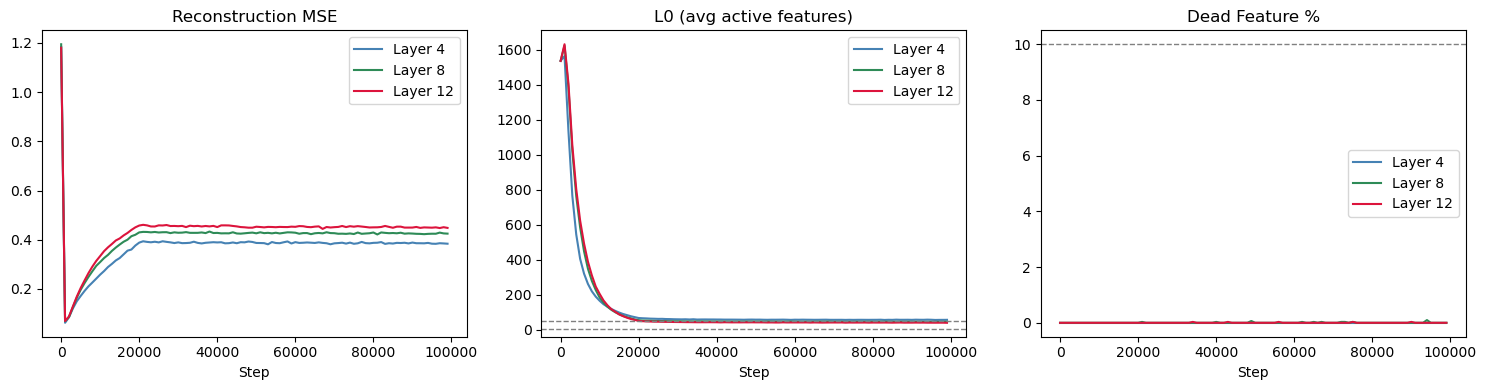

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for log, label, color in [(log4, 'Layer 4', 'steelblue'), (log8, 'Layer 8', 'seagreen'), (log12, 'Layer 12', 'crimson')]:
    s = log['step']
    axes[0].plot(s, log['mse'],      label=label, color=color)
    axes[1].plot(s, log['l0'],       label=label, color=color)
    axes[2].plot(s, log['dead_pct'], label=label, color=color)
axes[1].axhline(y=5,  color='gray', linestyle='--', linewidth=1)
axes[1].axhline(y=50, color='gray', linestyle='--', linewidth=1)
axes[2].axhline(y=10, color='gray', linestyle='--', linewidth=1)
for ax, title in zip(axes, ['Reconstruction MSE', 'L0 (avg active features)', 'Dead Feature %']):
    ax.set_title(title); ax.set_xlabel('Step'); ax.legend()
plt.tight_layout()
plt.savefig('../checkpoints/training_curves.png', dpi=150)
plt.show()